In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 4** - Optimal Product Placement

- Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly.

- To speed up decision-making, an ML model approximates these results within hours.
  - The model has **four hyperparameters** to tune, and its output reflects the _difference from the expensive baseline_.
    - Because the system is _dynamic_ and _full of local optima_.
    - It requires **careful tuning** and **robust validation** to find reliable, near-optimal solutions.

- **Inputs** = 4D array (30, 4)

- **Outputs** = 1D array (30, )

- **Goal** - Maximization


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.112450, 0.456812, 0.901233, 0.005678], dtype=np.float64)
Y_w1_new_point = np.array([-21.85692716767331], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_4\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 4: ", X_updated)
print("Updated Outputs (Y) - Function 4: ", Y_updated)

Updated Inputs (X) - Function 4:  [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.

### **Interpretation of the output and potential next steps to improve the model**

- I will be moving away from the random search as I got an initial impression of the 3D space.

- Now my current strategy is going to be to continue using the expected improvement surrogate model to find the best next query points.
  - I have explored this in detail in Week 1 function 3 analysis section.

- For the Wharehouse Logistics function I got an output value = -21.857
  - This indicates a significant deviation from the ideal baseline.
  - I think this means that my current current configuration likely resulted in high operational costs or severe logistical bottlenecks.

  - I hoping using this more strategic appraoch using expected improvements I can get a better score in this weeks outputs.


### **Bayesian Optimisation** - Matern kernel with Gaussian Proceess Regressor


- For this particular problem I am using the Matern kerenl as in comparison the RBF kerel is a bit too smooth whereas in this paricular looking at the use case we need to use a Matern.
  - It allows the model to recognize sharp changes in the warehouse efficiency surface.

- For the noise I am going to go quite low (`1e-3`) as the model is an approximation, meaning the output is probably consistent.

- I have also added 4 legnthscales in order to measure the impact that each variable has on the overall model a lot better.
  - I will be using this to see if this improves the results and makes the model more critical.


In [5]:
kernel = Matern(length_scale=[1.0]*4, nu=1.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

model.fit(X_updated, Y_updated)

GaussianProcessRegressor(alpha=0.001,
                         kernel=Matern(length_scale=[1, 1, 1, 1], nu=1.5),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvements (EI)


- After some research, EI seems to be an industry standard for 4D+ spaces.
  - I found out that the main reason for this - _It excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._

- It is important to note that the 1e-8 used in the calulation for z is used as without this I was getting `MemeoryError`
  - In a 4D model can become "too certain" about a point it has already seen, making the uncertainty ($\sigma$) zero.
  - After some research on why this error was occuring I found out that the Computers can't divide by zero. Adding this tiny "jitter" ensures the code remains robust and finishes the calculation without crashing your environment.

  I thought that + 1e-9 made the Expected Improvement calculation smooth and continuous.


In [6]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    
    return ei.ravel()

# Calculate the values using the function
y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, (10000, 4))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

# Find the best index from the calculated values
best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 4 - Bayesian Optimisation (EI): "
      f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")

Next Submission for Function 4 - Bayesian Optimisation (EI): 0.387195-0.490423-0.430710-0.405493


### **Visualisation of the search map and progress plot**


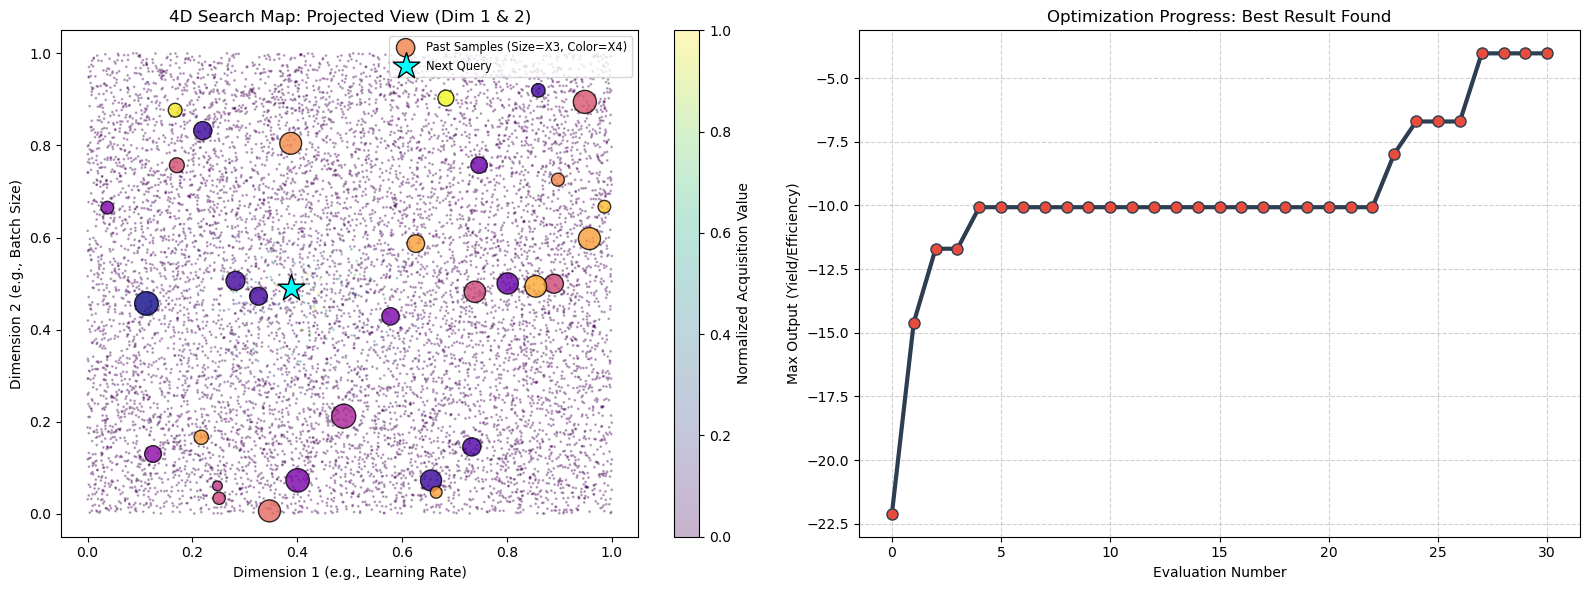

Strategic Result: Next point to query is at [0.387195-0.490423-0.430710-0.405493] with Expected Improvement value of 1.529435


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data for Progress Plot
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Normalize 3rd and 4th dimensions for visualization scaling
# We use X_updated[:, 2] for Size and X_updated[:, 3] for a Color tint if needed
x3_scaled = (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12)
past_sizes = 50 + (250 * x3_scaled) # Scaling point size by the 3rd dimension

# 3. The Search Map: 4D Projection
# We plot the Acquisition Function (EI/PI) background as 2D
acquisition_function = ei_values
acq_norm = (acquisition_function - np.nanmin(acquisition_function)) / (np.nanmax(acquisition_function) - np.nanmin(acquisition_function) + 1e-12)

# Background: Expected Improvement hotspots (assuming grid is in Dim 0 and 1)
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.3)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized Acquisition Value')

# Past Samples: Colored by the 4th dimension (X4) and sized by the 3rd dimension (X3)
past_sc = ax1.scatter(X_updated[:, 0], X_updated[:, 1], 
                      c=X_updated[:, 3], # Color by 4th Dimension
                      cmap='plasma', 
                      s=past_sizes,       # Size by 3rd Dimension
                      edgecolors='black', 
                      alpha=0.8, 
                      label='Past Samples (Size=X3, Color=X4)')

# Next Query: Highlighted clearly
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=400, edgecolors='black', label='Next Query')

ax1.set_title('4D Search Map: Projected View (Dim 1 & 2)')
ax1.set_xlabel('Dimension 1 (e.g., Learning Rate)')
ax1.set_ylabel('Dimension 2 (e.g., Batch Size)')
ax1.legend(loc='upper right', fontsize='small')

# 4. Progress Plot
ax2.plot(running_max, color='#2c3e50', linewidth=3, marker='o', markersize=8, markerfacecolor='#e74c3c')
ax2.set_title('Optimization Progress: Best Result Found')
ax2.set_xlabel('Evaluation Number')
ax2.set_ylabel('Max Output (Yield/Efficiency)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Strategic Result: Next point to query is at [{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}] with Expected Improvement value of {ei_values[best_idx]:.6f}")